Nombre: Emilio Rico Hernández
Clase: 9
Challenge: Machine Learning Arena
Fecha: 2026-09-25

# Challenge 9 — Machine Learning Arena

Una inmobiliaria quiere estimar el precio de una vivienda a partir de sus características. Con `viviendas_reto.csv` (800 viviendas) comparo varios modelos para ver cuál generaliza mejor, o sea, cuál predice mejor viviendas nuevas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("viviendas_reto.csv")
df.head()

,metros,habitaciones,banios,antiguedad,distancia_centro,precio
0,100.5,4,2.0,5,10.0,2620000
1,43.6,2,1.0,21,3.0,1466000
2,166.3,2,2.0,13,4.2,3536000
3,77.3,3,2.0,50,6.3,1898000
4,112.4,2,1.0,26,25.5,2049000


## Fase 1 — Auditoría

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (800, 6)
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   metros            800 non-null    float64
 1   habitaciones      800 non-null    int64  
 2   banios            794 non-null    float64
 3   antiguedad        800 non-null    int64  
 4   distancia_centro  800 non-null    float64
 5   precio            800 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 37.6 KB


In [3]:
print(df.isna().sum())
print("Duplicados:", df.duplicated().sum())

metros              0
habitaciones        0
banios              6
antiguedad          0
distancia_centro    0
precio              0
dtype: int64
Duplicados: 0


In [4]:
df.describe()

,metros,habitaciones,banios,antiguedad,distancia_centro,precio
count,800.000000,800.000000,794.000000,800.00000,800.000000,8.000000e+02
mean,114.775375,2.966250,2.042821,14.81875,6.866750,2.751383e+06
std,44.385040,1.063732,0.937212,9.67253,6.861149,8.322200e+05
min,30.000000,1.000000,1.000000,0.00000,0.300000,8.020000e+05
25%,82.525000,2.000000,1.000000,8.00000,1.975000,2.170000e+06
50%,113.100000,3.000000,2.000000,13.00000,4.700000,2.768500e+06
75%,146.650000,4.000000,3.000000,20.00000,9.600000,3.277500e+06
max,247.100000,5.000000,4.000000,50.00000,35.000000,8.696600e+06


In [5]:
# Variables sospechosas
print("Viviendas con metros == 30:", (df["metros"] == 30).sum())
print("Viviendas a más de 25 km del centro:", (df["distancia_centro"] > 25).sum())

# Precios raros: residuo grande de una recta precio ~ metros (solo para auditar, no borro nada)
pendiente, ordenada = np.polyfit(df["metros"], df["precio"], 1)
residuo = df["precio"] - (pendiente * df["metros"] + ordenada)
raros = df[residuo > 3 * residuo.std()]
print("Residuos de las sospechosas:", residuo[raros.index].round().tolist())
print("Siguiente residuo más alto:", round(residuo.drop(raros.index).max()))
raros

Viviendas con metros == 30: 27
Viviendas a más de 25 km del centro: 25
Residuos de las sospechosas: [2294790.0, 3146141.0, 3461593.0, 5055243.0]
Siguiente residuo más alto: 718352


,metros,habitaciones,banios,antiguedad,distancia_centro,precio
252,69.8,3,3.0,23,3.5,4281200
335,109.9,3,4.0,35,2.5,5814600
360,103.9,3,4.0,10,0.6,6028000
545,167.1,4,3.0,19,4.1,8696600


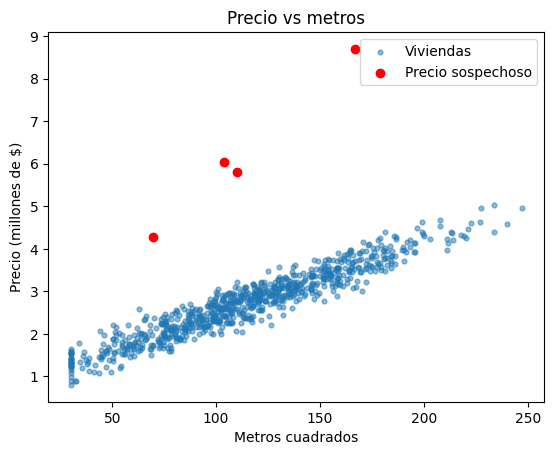

In [6]:
plt.scatter(df["metros"], df["precio"] / 1e6, s=12, alpha=0.5, label="Viviendas")
plt.scatter(raros["metros"], raros["precio"] / 1e6, color="red", label="Precio sospechoso")
plt.title("Precio vs metros")
plt.xlabel("Metros cuadrados")
plt.ylabel("Precio (millones de $)")
plt.legend()
plt.show()

Son 800 viviendas y 6 columnas numéricas. Solo `banios` tiene faltantes (6) y no hay duplicados. Los rangos son razonables (30 a 247 m², 0 a 50 años, 0.3 a 35 km al centro, $802 mil a $8.7 M de precio).

Lo raro: 27 viviendas miden exactamente 30 m² (el mínimo) y 25 están a más de 25 km del centro. Además, 4 viviendas (252, 335, 360 y 545) cuestan entre $2.3 M y $5.1 M más de lo esperado para sus metros (el siguiente residuo más alto es de $718 mil). No las elimino: no sé si son errores o propiedades de lujo.

## Fase 2 — Definir X e y

In [7]:
y = df["precio"]
X = df.drop(columns="precio")
print(X.columns.tolist())
print(df.corr()["precio"].round(2))

['metros', 'habitaciones', 'banios', 'antiguedad', 'distancia_centro']
metros              0.91
habitaciones        0.11
banios              0.05
antiguedad          0.01
distancia_centro   -0.08
precio              1.00
Name: precio, dtype: float64


Uso las 5 columnas restantes: describen tamaño, distribución, edad y ubicación, y ninguna se calcula con el precio (sin Data Leakage). `metros` casi explica el precio sola (correlación de 0.91); las demás correlacionan poco, pero eso es una por una, no combinadas.

## Fase 3 — Train/Test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Relleno los baños faltantes con la mediana del train (también en el test)
mediana = X_train["banios"].median()
X_train = X_train.fillna({"banios": mediana})
X_test = X_test.fillna({"banios": mediana})

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Viviendas sospechosas en train:", X_train.index.isin(raros.index).sum(), "| en test:", X_test.index.isin(raros.index).sum())

Train: (640, 5) | Test: (160, 5)
Viviendas sospechosas en train: 2 | en test: 2


Quedaron 640 viviendas de entrenamiento y 160 de prueba, y rellené `banios` con la mediana del train. El azar dejó 2 de las 4 sospechosas en cada grupo; con solo 160 de prueba, las del test pueden inflar el error (Fases 7 y 9).

## Fase 4 — Baseline

In [9]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
mae_baseline = mean_absolute_error(y_test, baseline.predict(X_test))
print(f"MAE baseline: ${mae_baseline:,.0f}")

MAE baseline: $683,370


Predecir siempre el promedio del train da un MAE de $683,370 en el test.

## Fase 5 y 6 — Torneo y métricas

In [10]:
modelos = {
    "Baseline": baseline,
    "Lineal": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Árbol": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
}

filas = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    filas.append({"Modelo": nombre,
                  "MAE": mean_absolute_error(y_test, pred),
                  "RMSE": mean_squared_error(y_test, pred) ** 0.5,
                  "R2": r2_score(y_test, pred)})

tabla = pd.DataFrame(filas).set_index("Modelo")
ganador = tabla.drop(index="Baseline")["MAE"].idxmin()
print("Ganador (menor MAE):", ganador)
tabla.round({"MAE": 0, "RMSE": 0, "R2": 3})

Ganador (menor MAE): Lineal


,MAE,RMSE,R2
Modelo,,,
Baseline,683370.0,936604.0,-0.007
Lineal,179050.0,484646.0,0.731
KNN,258540.0,549178.0,0.654
Árbol,312302.0,638464.0,0.532
Random Forest,216384.0,520927.0,0.689


El Lineal gana en las tres métricas: MAE de $179,050, RMSE de $484,646 y R² de 0.731, y todos los modelos superan al baseline (R² de -0.007). Me sorprendió que le gane al Random Forest ($216,384), pero el precio depende casi linealmente de los metros y la regresión aprende esa recta directamente; el árbol y el KNN la aproximan con escalones o vecinos.

## Fase 7 — Generalización

In [11]:
for nombre, modelo in modelos.items():
    mae_tr = mean_absolute_error(y_train, modelo.predict(X_train))
    mae_te = mean_absolute_error(y_test, modelo.predict(X_test))
    print(f"{nombre:14s} MAE train: {mae_tr:>9,.0f} | MAE test: {mae_te:>9,.0f} | brecha: {mae_te - mae_tr:>9,.0f}")

# Detalle del ganador: el error mediano dice si la brecha viene de todas las viviendas o de pocas
err_tr = (y_train - modelos[ganador].predict(X_train)).abs()
err_te = (y_test - modelos[ganador].predict(X_test)).abs()
print(f"\n{ganador}: brecha relativa del MAE = {err_te.mean() / err_tr.mean() - 1:.0%}")
print(f"Error mediano train: {err_tr.median():,.0f} | test: {err_te.median():,.0f}")

Baseline       MAE train:   648,255 | MAE test:   683,370 | brecha:    35,115
Lineal         MAE train:   135,777 | MAE test:   179,050 | brecha:    43,273
KNN            MAE train:   167,274 | MAE test:   258,540 | brecha:    91,266
Árbol          MAE train:         0 | MAE test:   312,302 | brecha:   312,302
Random Forest  MAE train:    62,647 | MAE test:   216,384 | brecha:   153,737

Lineal: brecha relativa del MAE = 32%
Error mediano train: 109,696 | test: 110,339


En el Lineal el MAE pasa de $135,777 (train) a $179,050 (test), una brecha de 32% que parece preocupante. Pero el error mediano casi no cambia ($109,696 contra $110,339): las viviendas normales se predicen igual de bien, y la brecha viene de pocas viviendas con errores enormes (las 2 sospechosas del test). No veo overfitting importante en el ganador.

En los demás sí: el Árbol memoriza el train (MAE de $0 contra $312,302 en test) y el Random Forest pasa de $62,647 a $216,384.

## Fase 8 — Hiperparámetros

El Lineal no tiene `n_neighbors`, `max_depth` ni `n_estimators`, así que los modifico en KNN, Árbol y Random Forest. Elijo el valor con validación cruzada de 5 folds dentro del train y luego comparo en el test antes y después.

In [12]:
for k in [3, 5, 10, 20, 30]:
    cv = cross_val_score(KNeighborsRegressor(n_neighbors=k), X_train, y_train, cv=5, scoring="neg_mean_absolute_error")
    print("KNN, n_neighbors =", k, "-> MAE CV:", round(-cv.mean()))

for d in [2, 4, 6, 8, None]:
    cv = cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=42), X_train, y_train, cv=5, scoring="neg_mean_absolute_error")
    print("Árbol, max_depth =", d, "-> MAE CV:", round(-cv.mean()))

for n in [50, 100, 300]:
    cv = cross_val_score(RandomForestRegressor(n_estimators=n, random_state=42), X_train, y_train, cv=5, scoring="neg_mean_absolute_error")
    print("Random Forest, n_estimators =", n, "-> MAE CV:", round(-cv.mean()))

KNN, n_neighbors = 3 -> MAE CV: 215197
KNN, n_neighbors = 5 -> MAE CV: 207928
KNN, n_neighbors = 10 -> MAE CV: 204676
KNN, n_neighbors = 20 -> MAE CV: 200972
KNN, n_neighbors = 30 -> MAE CV: 203659
Árbol, max_depth = 2 -> MAE CV: 291909
Árbol, max_depth = 4 -> MAE CV: 224671
Árbol, max_depth = 6 -> MAE CV: 210990
Árbol, max_depth = 8 -> MAE CV: 224935
Árbol, max_depth = None -> MAE CV: 236014
Random Forest, n_estimators = 50 -> MAE CV: 171024
Random Forest, n_estimators = 100 -> MAE CV: 170912
Random Forest, n_estimators = 300 -> MAE CV: 170162


In [13]:
# Uso el mejor valor de cada lista
ajustados = {"KNN": KNeighborsRegressor(n_neighbors=20),
             "Árbol": DecisionTreeRegressor(max_depth=6, random_state=42),
             "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42)}

for nombre, modelo in ajustados.items():
    modelo.fit(X_train, y_train)
    despues = mean_absolute_error(y_test, modelo.predict(X_test))
    print(f"{nombre}: MAE test antes {tabla.loc[nombre, 'MAE']:,.0f} -> después {despues:,.0f}")

KNN: MAE test antes 258,540 -> después 245,680
Árbol: MAE test antes 312,302 -> después 257,557
Random Forest: MAE test antes 216,384 -> después 217,385


En el KNN, pasar de 5 a 20 vecinos baja el MAE del test de $258,540 a $245,680 (-5.0%). En el Árbol, 2 niveles es muy poco ($291,909 en validación), sin límite sobreajusta ($236,014) y con 6 baja a $210,990; en el test pasa de $312,302 a $257,557 (-17.5%). En el Random Forest, 300 árboles en vez de 100 casi no cambian nada y en el test empeoró 0.5% (ruido). Ninguno alcanza al Lineal ($179,050); el mejor ajustado es el Random Forest con $217,385.

## Fase 9 — Errores

In [14]:
errores = X_test.assign(precio_real=y_test, precio_predicho=modelos[ganador].predict(X_test).round(0))
errores["error"] = errores["precio_real"] - errores["precio_predicho"]
errores["error_abs"] = errores["error"].abs()
errores["precio_m2"] = (errores["precio_real"] / errores["metros"]).round(0)

top5 = errores.sort_values("error_abs", ascending=False).head(5)
print("¿Están en la lista de sospechosas?", top5.index.isin(raros.index).tolist())
top5

¿Están en la lista de sospechosas? [True, True, False, False, False]


,metros,habitaciones,banios,antiguedad,distancia_centro,precio_real,precio_predicho,error,error_abs,precio_m2
545,167.1,4,3.0,19,4.1,8696600,3889527.0,4807073.0,4807073.0,52044.0
360,103.9,3,4.0,10,0.6,6028000,2814933.0,3213067.0,3213067.0,58017.0
65,47.1,3,2.0,19,0.5,1224000,1634583.0,-410583.0,410583.0,25987.0
446,65.6,3,3.0,6,10.6,2343000,1971289.0,371711.0,371711.0,35716.0
316,97.5,3,3.0,12,21.7,2017000,2386088.0,-369088.0,369088.0,20687.0


In [15]:
cols = ["precio_real", "precio_m2", "metros", "antiguedad", "habitaciones", "distancia_centro"]
resto = errores.drop(index=top5.index)
print(pd.DataFrame({"Top 5": top5[cols].mean(), "Resto": resto[cols].mean()}).round(1))

print(f"\nLos 2 peores errores suman {top5['error_abs'].head(2).sum() / errores['error_abs'].sum():.0%} del error total del test")
print(f"MAE del test: {errores['error_abs'].mean():,.0f} | sin esos 2: {errores['error_abs'].drop(top5.index[:2]).mean():,.0f}")

                      Top 5      Resto
precio_real       4061720.0  2771335.5
precio_m2           38490.2    25025.9
metros                 96.2      117.7
antiguedad             13.2       14.3
habitaciones            3.2        2.9
distancia_centro        7.5        6.2

Los 2 peores errores suman 28% del error total del test
MAE del test: 179,050 | sin esos 2: 130,556


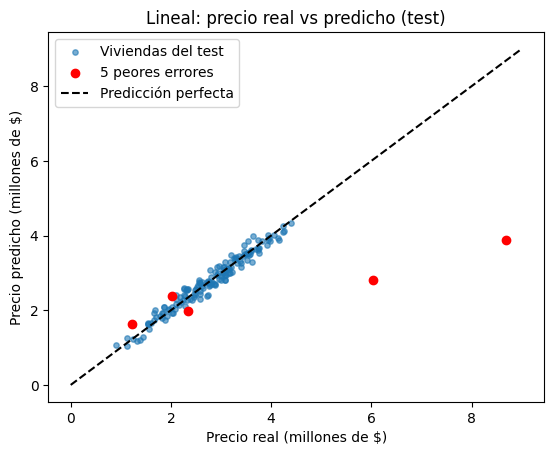

In [16]:
plt.scatter(errores["precio_real"] / 1e6, errores["precio_predicho"] / 1e6, s=15, alpha=0.6, label="Viviendas del test")
plt.scatter(top5["precio_real"] / 1e6, top5["precio_predicho"] / 1e6, color="red", label="5 peores errores")
plt.plot([0, 9], [0, 9], "k--", label="Predicción perfecta")
plt.title(f"{ganador}: precio real vs predicho (test)")
plt.xlabel("Precio real (millones de $)")
plt.ylabel("Precio predicho (millones de $)")
plt.legend()
plt.show()

Los dos peores errores son las viviendas 545 y 360, dos de las 4 sospechosas: el modelo predice $3.89 M y $2.81 M para viviendas de $8.70 M y $6.03 M. Suman el 28% del error total del test siendo 2 de 160 viviendas, y sin ellas el MAE baja de $179,050 a $130,556. Su precio por m² ($52 mil y $58 mil) es más del doble del resto ($25 mil), y no veo que ninguna de las variables disponibles lo explique.

Los otros tres (65, 446 y 316) tienen errores de $369 mil a $411 mil, sin patrón claro. El top 5 tiene mayor precio ($4.06 M contra $2.77 M) y es algo más chico (96 contra 118 m²). La antigüedad casi no los distingue (13 contra 14 años), ni la distancia al centro (7.5 contra 6.2 km); lo común es un precio por m² alto.

## Preguntas de reflexión

1. **¿Cuál modelo ganó?** El Lineal (MAE $179,050, R² 0.731).
2. **¿Superó claramente al baseline?** Sí: $179,050 contra $683,370 de MAE, 74% menos error.
3. **¿Existe overfitting?** En el Lineal no (error mediano casi igual en train y test); en el Árbol y el Random Forest sí.
4. **¿Cambió el resultado al modificar hiperparámetros?** Poco en el KNN (-5.0%), bastante en el Árbol (-17.5%), nada en el Random Forest (+0.5%). Ninguno alcanzó al Lineal.
5. **¿Dónde falla más el modelo?** En viviendas con precio muy superior al que sugiere su tamaño (545 y 360).
6. **¿Qué modelo recomendarías?** El Lineal: es el más preciso, no sobreajusta y es fácil de explicar.

## Conclusión ejecutiva

In [17]:
supera = "sí" if tabla.loc[ganador, "MAE"] < mae_baseline else "no"
overfitting = "presenta" if err_te.median() > 1.3 * err_tr.median() else "no presenta"
print(f"El mejor modelo fue {ganador}, con un MAE de ${tabla.loc[ganador, 'MAE']:,.0f}.")
print(f"El modelo {supera} supera al baseline (${mae_baseline:,.0f}) y {overfitting} evidencia importante de overfitting (juzgado con el error mediano).")

El mejor modelo fue Lineal, con un MAE de $179,050.
El modelo sí supera al baseline ($683,370) y no presenta evidencia importante de overfitting (juzgado con el error mediano).


El mejor modelo fue la Regresión Lineal, con un MAE de $179,050 (baseline: $683,370). El modelo sí supera al baseline y no presenta evidencia importante de overfitting: su MAE de test es 32% mayor que el de train, pero el error mediano es casi igual (~$110 mil) y la diferencia viene de 2 viviendas atípicas. Pendiente: revisar las 4 viviendas atípicas y los 27 registros de 30 m².